In [2]:
# ============================================================
# МОДУЛЬ 1: ИМПОРТЫ И НАСТРОЙКИ
# ============================================================
# Запустите эту ячейку первой

import os
import time
import copy
import warnings
from datetime import datetime
from collections import defaultdict
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torch.cuda.amp import autocast, GradScaler
from PIL import Image

# Отключаем предупреждения
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("✅ МОДУЛЬ 1: БИБЛИОТЕКИ ЗАГРУЖЕНЫ")
print("=" * 70)

# ============================================================
# КОНФИГУРАЦИЯ УСТРОЙСТВА И ГИПЕРПАРАМЕТРЫ
# ============================================================

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ОПТИМИЗАЦИЯ CUDA
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    
    # Автоматический выбор алгоритмов для сверток
    import torch.backends.cudnn as cudnn
    cudnn.benchmark = True  # Ускоряет свертки
    # cudnn.deterministic = True  # Для воспроизводимости (замедляет)
    
    print(f"🔥 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 Видеопамять: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"🔢 Количество GPU: {torch.cuda.device_count()}")
    print(f"📦 CUDA: {torch.version.cuda}")
    print(f"⚡ cuDNN: {cudnn.version()}")
    print(f"🐍 PyTorch: {torch.__version__}")
    
    # Компиляция модели (PyTorch 2.0+)
    USE_COMPILE = hasattr(torch, 'compile')
    if USE_COMPILE:
        print("✨ torch.compile доступен")
else:
    print("⚠️ CUDA недоступна, будет использоваться CPU")
    USE_COMPILE = False

print("=" * 70)

# ============================================
# ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ПОД GPU
# ============================================

# Автоматический подбор batch size и workers
if torch.cuda.is_available():
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    
    if gpu_memory_gb >= 12:
        BATCH_SIZE = 128
        NUM_WORKERS = min(8, os.cpu_count())
        ACCUMULATION_STEPS = 1
    elif gpu_memory_gb >= 8:
        BATCH_SIZE = 96
        NUM_WORKERS = min(6, os.cpu_count())
        ACCUMULATION_STEPS = 1
    elif gpu_memory_gb >= 6:
        BATCH_SIZE = 64
        NUM_WORKERS = min(4, os.cpu_count())
        ACCUMULATION_STEPS = 1
    else:
        BATCH_SIZE = 32
        NUM_WORKERS = 2
        ACCUMULATION_STEPS = 2
else:
    BATCH_SIZE = 16
    NUM_WORKERS = 2
    ACCUMULATION_STEPS = 2

print(f"📊 Batch Size: {BATCH_SIZE}")
print(f"👷 Num Workers: {NUM_WORKERS}")
print(f"🔄 Accumulation Steps: {ACCUMULATION_STEPS}")

# ============================================
# ГИПЕРПАРАМЕТРЫ ОБУЧЕНИЯ
# ============================================

NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
IMAGE_SIZE = 224
RANDOM_SEED = 42

# Настройка путей (для Windows)
BASE_DIR = r'F:/Jupiter/HW_Simpsons/5_10_archive'
TRAIN_DIR = os.path.join(BASE_DIR, 'simpsons_dataset')
TEST_DIR = os.path.join(BASE_DIR, 'kaggle_simpson_testset')
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Установка seed для воспроизводимости
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Проверка путей
print(f"\n📁 Train Dir: {TRAIN_DIR}")
print(f"📁 Test Dir: {TEST_DIR}")
print(f"📁 Checkpoint Dir: {CHECKPOINT_DIR}")
print(f"✅ Train exists: {os.path.exists(TRAIN_DIR)}")
print(f"✅ Test exists: {os.path.exists(TEST_DIR)}")
print("=" * 70)

# Нормализация ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

✅ МОДУЛЬ 1: БИБЛИОТЕКИ ЗАГРУЖЕНЫ
🔥 GPU: NVIDIA GeForce RTX 3060
💾 Видеопамять: 12.00 GB
🔢 Количество GPU: 1
📦 CUDA: 12.1
⚡ cuDNN: 90100
🐍 PyTorch: 2.5.1+cu121
✨ torch.compile доступен
📊 Batch Size: 96
👷 Num Workers: 6
🔄 Accumulation Steps: 1

📁 Train Dir: F:/Jupiter/HW_Simpsons/5_10_archive\simpsons_dataset
📁 Test Dir: F:/Jupiter/HW_Simpsons/5_10_archive\kaggle_simpson_testset
📁 Checkpoint Dir: F:/Jupiter/HW_Simpsons/5_10_archive\checkpoints
✅ Train exists: True
✅ Test exists: True


In [3]:
# ============================================================
# МОДУЛЬ 2: КЛАСС DATASET И DATALOADER
# ============================================================
# Запустите после МОДУЛЬ 1

class SimpsonsDataset(Dataset):
    """Оптимизированный Dataset для загрузки изображений Симпсонов"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Загрузка изображения
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        # Применение трансформаций
        if self.transform:
            image = self.transform(image)
        
        return image, label


def load_dataset_from_directory(data_dir):
    """
    Загружает датасет из директории с папками классов
    Возвращает: image_paths, labels, class_names
    """
    class_names = sorted(os.listdir(data_dir))
    image_paths = []
    labels = []
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
            
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_dir, img_name))
                labels.append(class_idx)
    
    return image_paths, labels, class_names


def create_datasets(train_transform, val_transform, train_dir=TRAIN_DIR):
    """
    Создает train/val датасеты с stratified split
    """
    print("=" * 70)
    print("📂 СОЗДАНИЕ ДАТАСЕТОВ")
    print("=" * 70)
    
    # Загрузка данных
    image_paths, labels, class_names = load_dataset_from_directory(train_dir)
    
    # Stratified split
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        image_paths, labels,
        test_size=0.2,
        stratify=labels,
        random_state=RANDOM_SEED
    )
    
    # Создание датасетов
    train_dataset = SimpsonsDataset(train_paths, train_labels, train_transform)
    val_dataset = SimpsonsDataset(val_paths, val_labels, val_transform)
    
    print(f"🏷️  Классов: {len(class_names)}")
    print(f"📊 Train: {len(train_dataset)} изображений")
    print(f"📊 Val: {len(val_dataset)} изображений")
    print(f"📝 Пример классов: {class_names[:5]}...")
    print("=" * 70 + "\n")
    
    return train_dataset, val_dataset, class_names


def create_optimized_dataloaders(train_dataset, val_dataset):
    """
    Создает оптимизированные dataloaders для максимальной скорости
    
    Оптимизации:
    - num_workers: параллельная загрузка данных
    - pin_memory: ускорение передачи CPU→GPU
    - persistent_workers: не пересоздавать workers между эпохами
    - prefetch_factor: предварительная загрузка батчей
    - non_blocking: асинхронная передача данных
    """
    print("=" * 70)
    print("⚡ СОЗДАНИЕ ОПТИМИЗИРОВАННЫХ DATALOADERS")
    print("=" * 70)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,          # Ускоряет передачу на GPU
        persistent_workers=True,   # Не пересоздавать workers
        prefetch_factor=2,         # Предварительная загрузка
        drop_last=True             # Дропнуть последний неполный батч
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2
    )
    
    print(f"📦 Batch size: {BATCH_SIZE}")
    print(f"👷 Workers: {NUM_WORKERS}")
    print(f"🔄 Train batches: {len(train_loader)}")
    print(f"🔄 Val batches: {len(val_loader)}")
    print("=" * 70 + "\n")
    
    return train_loader, val_loader

# Количество классов (определяется автоматически)
_, _, class_names_temp = load_dataset_from_directory(TRAIN_DIR)
NUM_CLASSES = len(class_names_temp)
print(f"🎯 Количество классов: {NUM_CLASSES}\n")

🎯 Количество классов: 42



In [4]:
# ============================================================
# МОДУЛЬ 3: АУГМЕНТАЦИИ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================
# Запустите после МОДУЛЬ 2

def get_transforms(augmentation_type='good'):
    """
    Возвращает трансформации для обучения и валидации
    
    Параметры:
    - augmentation_type: 
        'none' - без аугментаций
        'basic' - базовые аугментации
        'good' - хорошие аугментации (для лучшего качества)
        'bad' - плохие аугментации (ухудшение качества >10%)
        'very_bad' - очень плохие аугментации (сильное ухудшение)
    """
    
    # Базовый размер
    resize_transform = transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))
    
    # Базовая нормализация
    normalize = transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
    
    # Валидационные трансформации (одинаковые для всех)
    val_transform = transforms.Compose([
        resize_transform,
        transforms.ToTensor(),
        normalize
    ])
    
    # Тренировочные трансформации в зависимости от типа
    if augmentation_type == 'none':
        train_transform = transforms.Compose([
            resize_transform,
            transforms.ToTensor(),
            normalize
        ])
        
    elif augmentation_type == 'basic':
        train_transform = transforms.Compose([
            resize_transform,
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            normalize
        ])
        
    elif augmentation_type == 'good':
        # Хорошие аугментации для улучшения качества
        train_transform = transforms.Compose([
            resize_transform,
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1),
                scale=(0.9, 1.1)
            ),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
        ])
        
    elif augmentation_type == 'bad':
        # Плохие аугментации - сильно ухудшают качество
        train_transform = transforms.Compose([
            resize_transform,
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=30),  # Сильное вращение
            transforms.RandomAffine(
                degrees=15,  # Сильный поворот
                translate=(0.3, 0.3),  # Сильный сдвиг
                scale=(0.6, 1.4),  # Сильное масштабирование
                shear=10  # Сильный сдвиг
            ),
            transforms.ColorJitter(
                brightness=0.5,  # Сильное изменение яркости
                contrast=0.5,
                saturation=0.5,
                hue=0.3
            ),
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),  # Размытие
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.5, scale=(0.05, 0.3))  # Сильное вырезание
        ])
        
    elif augmentation_type == 'very_bad':
        # Очень плохие аугментации - экстремальное ухудшение
        train_transform = transforms.Compose([
            resize_transform,
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=45),  # Экстремальное вращение
            transforms.RandomAffine(
                degrees=30,
                translate=(0.4, 0.4),
                scale=(0.4, 1.6),
                shear=20
            ),
            transforms.ColorJitter(
                brightness=0.8,
                contrast=0.8,
                saturation=0.8,
                hue=0.5
            ),
            transforms.GaussianBlur(kernel_size=7, sigma=(0.5, 3.0)),  # Сильное размытие
            transforms.RandomPerspective(distortion_scale=0.5, p=0.5),  # Искажение перспективы
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.7, scale=(0.1, 0.5))  # Экстремальное вырезание
        ])
        
    else:
        raise ValueError(f"Неизвестный тип аугментаций: {augmentation_type}")
    
    print(f"🎨 Тип аугментаций: {augmentation_type}")
    return train_transform, val_transform


def visualize_augmentations(augmentation_types=['good', 'bad', 'very_bad'], num_samples=2):
    """Визуализирует влияние разных аугментаций"""
    print("=" * 70)
    print("🖼️  ВИЗУАЛИЗАЦИЯ АУГМЕНТАЦИЙ")
    print("=" * 70)
    
    # Получаем пример изображения
    sample_class = os.listdir(TRAIN_DIR)[0]
    sample_img_path = os.path.join(
        TRAIN_DIR, sample_class,
        os.listdir(os.path.join(TRAIN_DIR, sample_class))[0]
    )
    original_img = Image.open(sample_img_path).convert('RGB')
    
    num_types = len(augmentation_types) + 1  # +1 для original
    fig, axes = plt.subplots(num_samples, num_types, figsize=(5 * num_types, 4 * num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for sample_idx in range(num_samples):
        # Original
        axes[sample_idx, 0].imshow(original_img)
        axes[sample_idx, 0].set_title('Original', fontsize=12, fontweight='bold')
        axes[sample_idx, 0].axis('off')
        
        # Augmentations
        for col_idx, aug_type in enumerate(augmentation_types, 1):
            transform, _ = get_transforms(aug_type)
            
            # Применяем трансформацию несколько раз для разнообразия
            for _ in range(sample_idx + 1):
                transformed = transform(original_img)
            
            # Денормализация для отображения
            mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
            std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
            display_img = transformed * std + mean
            display_img = torch.clamp(display_img, 0, 1)
            display_img = transforms.ToPILImage()(display_img)
            
            axes[sample_idx, col_idx].imshow(display_img)
            axes[sample_idx, col_idx].set_title(aug_type, fontsize=12)
            axes[sample_idx, col_idx].axis('off')
    
    plt.suptitle('Влияние аугментаций на изображения', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("=" * 70 + "\n")

print("✅ МОДУЛЬ 3: АУГМЕНТАЦИИ ЗАГРУЖЕН\n")

✅ МОДУЛЬ 3: АУГМЕНТАЦИИ ЗАГРУЖЕН



In [5]:
# ============================================================
# МОДУЛЬ 4: СОЗДАНИЕ МОДЕЛЕЙ (VGG, EfficientNet, MobileNet)
# ============================================================
# Запустите после МОДУЛЬ 3

def create_model(model_name='efficientnet_b0', num_classes=NUM_CLASSES, 
                 pretrained=True, mode='feature_extractor'):
    """
    Создает модель для Transfer Learning
    
    Параметры:
    - model_name: 'vgg16_bn', 'efficientnet_b0', 'mobilenet_v3_small'
    - num_classes: количество классов
    - pretrained: использовать предобученные веса
    - mode: 'feature_extractor' (замороженные слои) или 'fine_tuning' (fine-tuning)
    """
    
    print("=" * 70)
    print(f"🏗️  СОЗДАНИЕ МОДЕЛИ: {model_name.upper()}")
    print("=" * 70)
    print(f"   Классов: {num_classes}")
    print(f"   Предобученная: {pretrained}")
    print(f"   Режим: {mode}")
    
    # Загрузка модели
    weights = 'IMAGENET1K_V1' if pretrained else None
    
    if model_name == 'vgg16_bn':
        model = models.vgg16_bn(weights=weights)
        
        # Получаем количество входных признаков
        num_features = model.classifier[0].in_features
        
        if mode == 'feature_extractor':
            # Замораживаем все слои
            for param in model.parameters():
                param.requires_grad = False
            print("   ✅ Все веса заморожены")
        elif mode == 'fine_tuning':
            # Размораживаем последние слои
            for param in model.features[-8:].parameters():
                param.requires_grad = True
            print("   ✅ Последние 8 блоков разморожены")
        
        # Заменяем классификатор
        model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=weights)
        
        if mode == 'feature_extractor':
            for param in model.parameters():
                param.requires_grad = False
            print("   ✅ Все веса заморожены")
        elif mode == 'fine_tuning':
            # Размораживаем последние блоки
            for param in model.features[-4:].parameters():
                param.requires_grad = True
            print("   ✅ Последние 4 блока разморожены")
        
        # Заменяем классификатор
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(model.features[-1].out_channels, num_classes)
        )
        
    elif model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=weights)
        
        if mode == 'feature_extractor':
            for param in model.parameters():
                param.requires_grad = False
            print("   ✅ Все веса заморожены")
        elif mode == 'fine_tuning':
            for param in model.features[-4:].parameters():
                param.requires_grad = True
            print("   ✅ Последние 4 блока разморожены")
        
        # Заменяем классификатор
        model.classifier = nn.Sequential(
            nn.Linear(model.features[-1].out_channels, 1024),
            nn.Hardswish(inplace=True),
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(1024, num_classes)
        )
        
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")
    
    # Перенос на устройство
    model = model.to(device)
    
    # Компиляция модели (PyTorch 2.0+)
    if USE_COMPILE:
        try:
            model = torch.compile(model)
            print("   ✅ Модель скомпилирована (torch.compile)")
        except Exception as e:
            print(f"   ⚠️  Компиляция недоступна: {e}")
    
    # Статистика параметров
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"   📊 Всего параметров: {total_params:,}")
    print(f"   📊 Обучаемых: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
    print("=" * 70 + "\n")
    
    return model


def get_model_info(model):
    """Выводит подробную информацию о модели"""
    print("=" * 70)
    print("📊 ИНФОРМАЦИЯ О МОДЕЛИ")
    print("=" * 70)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    
    print(f"Всего параметров: {total_params:,}")
    print(f"Обучаемых: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
    print(f"Замороженных: {frozen_params:,} ({100*frozen_params/total_params:.2f}%)")
    
    # Размер модели в памяти
    model_size_mb = total_params * 4 / (1024 ** 2)  # float32 = 4 bytes
    print(f"Размер модели: {model_size_mb:.2f} MB")
    print("=" * 70 + "\n")

print("✅ МОДУЛЬ 4: МОДЕЛИ ЗАГРУЖЕНЫ\n")

✅ МОДУЛЬ 4: МОДЕЛИ ЗАГРУЖЕНЫ



Визуализация LR Schedulers:
📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: STEP_LR


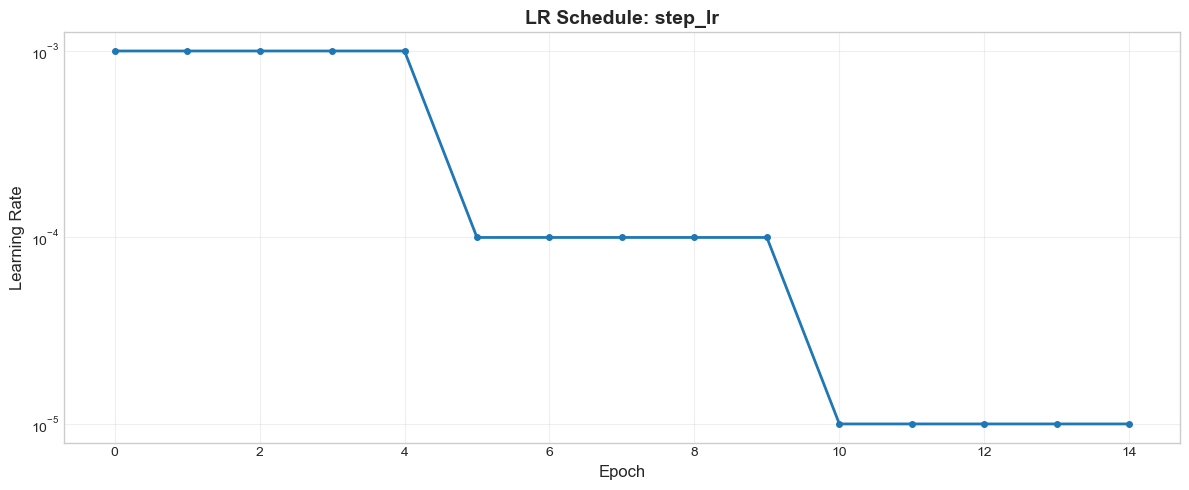

   Начальный LR: 0.001000
   Максимальный LR: 0.001000
   Конечный LR: 0.000010

📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: COSINE


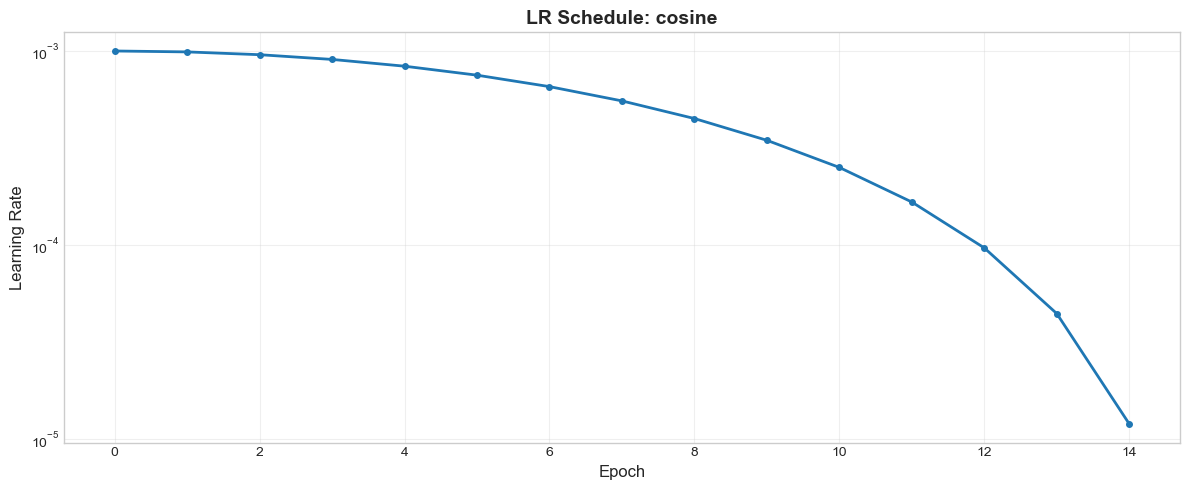

   Начальный LR: 0.001000
   Максимальный LR: 0.001000
   Конечный LR: 0.000012

📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: COSINE_WARM


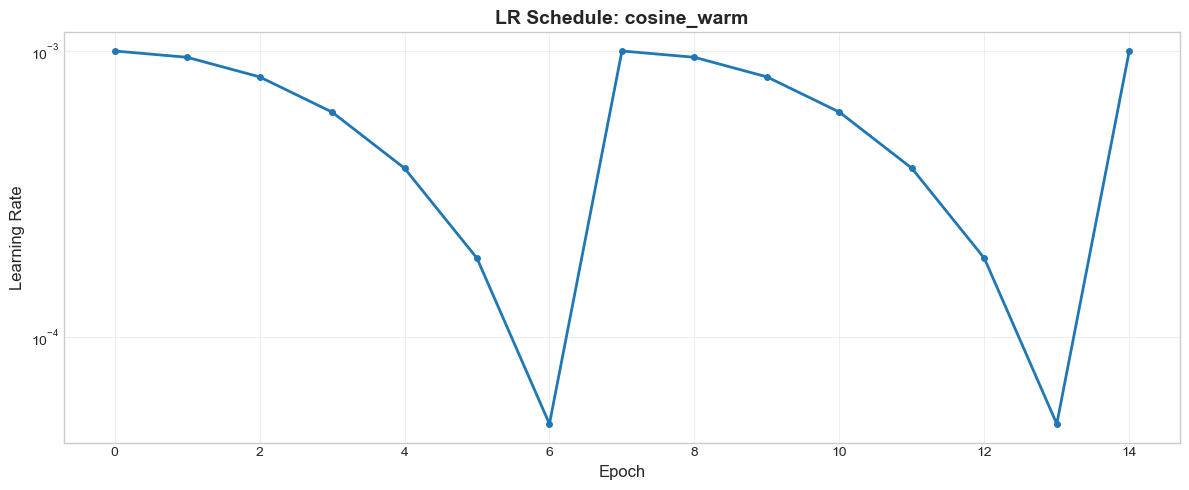

   Начальный LR: 0.001000
   Максимальный LR: 0.001000
   Конечный LR: 0.001000

📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: PLATEAU


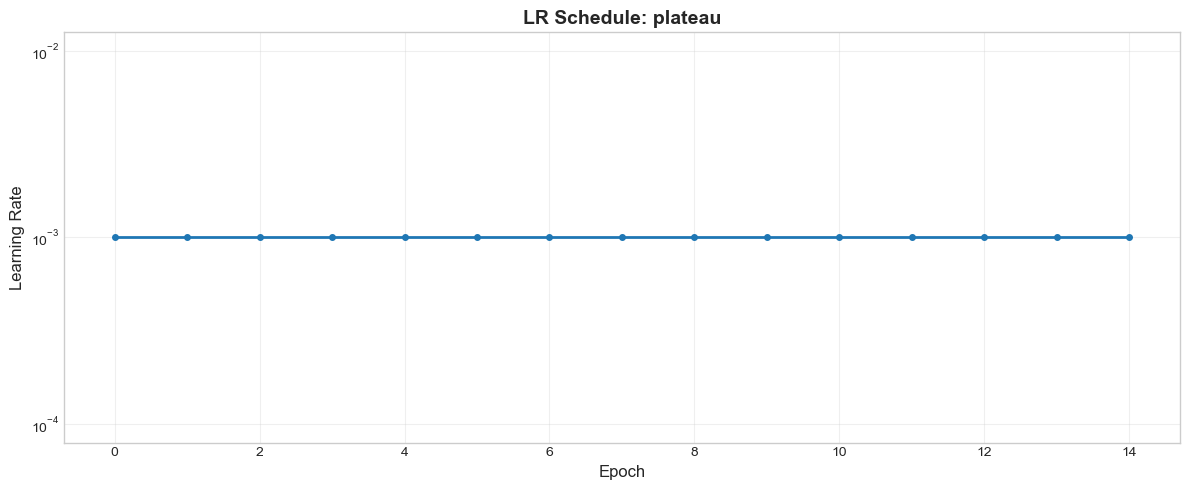

   Начальный LR: 0.001000
   Максимальный LR: 0.001000
   Конечный LR: 0.001000

📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: EXPONENTIAL


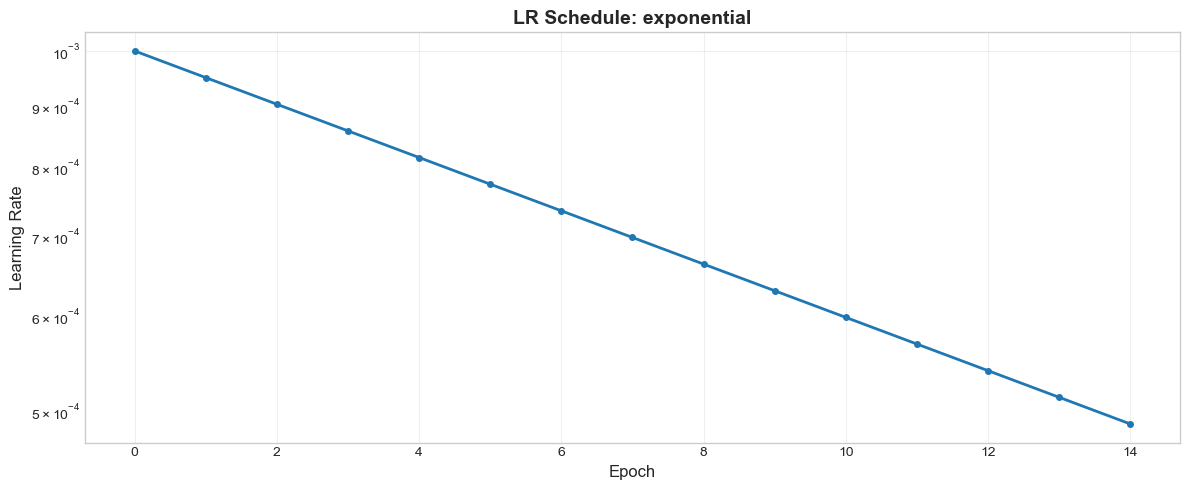

   Начальный LR: 0.001000
   Максимальный LR: 0.001000
   Конечный LR: 0.000488

📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: ONECYCLE


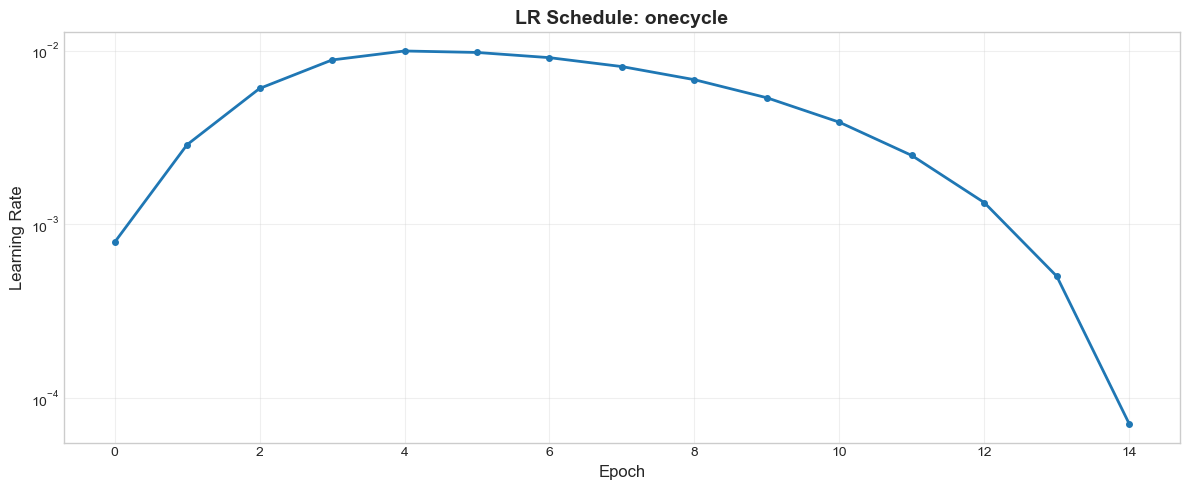

   Начальный LR: 0.000788
   Максимальный LR: 0.009945
   Конечный LR: 0.000071

✅ МОДУЛЬ 5: LR SCHEDULERS ЗАГРУЖЕН



In [6]:
# ============================================================
# МОДУЛЬ 5: LR SCHEDULERS
# ============================================================
# Запустите после МОДУЛЬ 4

def get_scheduler(optimizer, scheduler_name, num_epochs):
    """
    Создает scheduler по имени
    
    Доступные schedulers:
    - 'step_lr': StepLR - уменьшает LR с шагом
    - 'cosine': CosineAnnealingLR - косинусное затухание
    - 'cosine_warm': CosineAnnealingWarmRestarts - перезапуски
    - 'plateau': ReduceLROnPlateau - по метрике
    - 'exponential': ExponentialLR - экспоненциальное затухание
    - 'onecycle': OneCycleLR - один цикл
    - 'none': без scheduler
    """
    
    if scheduler_name == 'step_lr':
        scheduler = lr_scheduler.StepLR(
            optimizer,
            step_size=num_epochs // 3,
            gamma=0.1
        )
    elif scheduler_name == 'cosine':
        scheduler = lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs,
            eta_min=1e-6
        )
    elif scheduler_name == 'cosine_warm':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=num_epochs // 2,
            T_mult=1
        )
    elif scheduler_name == 'plateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=3,
            verbose=True,
            min_lr=1e-7
        )
    elif scheduler_name == 'exponential':
        scheduler = lr_scheduler.ExponentialLR(
            optimizer,
            gamma=0.95
        )
    elif scheduler_name == 'onecycle':
        scheduler = None  # OneCycleLR создается отдельно
    elif scheduler_name == 'none' or scheduler_name is None:
        scheduler = None
    else:
        raise ValueError(f"Неизвестный scheduler: {scheduler_name}")
    
    return scheduler


def plot_lr_schedule(scheduler_name, num_epochs=NUM_EPOCHS, initial_lr=LEARNING_RATE):
    """Визуализирует изменение learning rate"""
    print("=" * 70)
    print(f"📈 ВИЗУАЛИЗАЦИЯ LR SCHEDULE: {scheduler_name.upper()}")
    print("=" * 70)
    
    lrs = []
    epochs = list(range(num_epochs))
    
    # Создаем тестовую модель и оптимизатор
    test_model = nn.Linear(10, 2)
    test_optimizer = optim.Adam(test_model.parameters(), lr=initial_lr)
    
    # Создаем scheduler
    if scheduler_name == 'onecycle':
        scheduler = lr_scheduler.OneCycleLR(
            test_optimizer,
            max_lr=initial_lr * 10,
            epochs=num_epochs,
            steps_per_epoch=100
        )
        # Симулируем батчи
        for epoch in range(num_epochs):
            epoch_lrs = []
            for _ in range(100):
                scheduler.step()
                epoch_lrs.append(test_optimizer.param_groups[0]['lr'])
            lrs.append(np.mean(epoch_lrs))
    else:
        scheduler = get_scheduler(test_optimizer, scheduler_name, num_epochs)
        
        for epoch in range(num_epochs):
            lrs.append(test_optimizer.param_groups[0]['lr'])
            test_optimizer.step()
            test_optimizer.zero_grad()
            
            if scheduler is not None:
                if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(0.5 + 0.01 * epoch)
                else:
                    scheduler.step()
    
    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.plot(epochs, lrs, linewidth=2, marker='o', markersize=4)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title(f'LR Schedule: {scheduler_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()
    
    print(f"   Начальный LR: {lrs[0]:.6f}")
    print(f"   Максимальный LR: {max(lrs):.6f}")
    print(f"   Конечный LR: {lrs[-1]:.6f}")
    print("=" * 70 + "\n")

# Визуализируем все schedulers
print("Визуализация LR Schedulers:")
scheduler_list = ['step_lr', 'cosine', 'cosine_warm', 'plateau', 'exponential', 'onecycle']
for sched in scheduler_list:
    plot_lr_schedule(sched, NUM_EPOCHS)

print("✅ МОДУЛЬ 5: LR SCHEDULERS ЗАГРУЖЕН\n")

In [7]:
# ============================================================
# МОДУЛЬ 6: ФУНКЦИИ ОБУЧЕНИЯ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================
# Запустите после МОДУЛЯ 5

def train_one_epoch(model, dataloader, criterion, optimizer, device, 
                   scaler=None, accumulation_steps=1, scheduler=None):
    """Обучает одну эпоху с градиентным накоплением"""
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    optimizer.zero_grad()
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for batch_idx, (inputs, labels) in enumerate(progress_bar):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Mixed precision
        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps
            
            scaler.scale(loss).backward()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps
            loss.backward()
        
        # Gradient accumulation
        if (batch_idx + 1) % accumulation_steps == 0:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            
            optimizer.zero_grad()
            
            if scheduler is not None:
                scheduler.step()
        
        # Статистика
        running_loss += loss.item() * accumulation_steps * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        progress_bar.set_postfix({
            'loss': running_loss / total,
            'acc': 100. * correct / total
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Валидирует модель"""
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Validation", leave=False)
        
        for inputs, labels in progress_bar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({
                'loss': loss.item(),
                'acc': 100. * correct / total
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader,
               num_epochs=10, experiment_name='experiment', use_amp=True,
               accumulation_steps=1, save_checkpoints=True):
    """
    Полный цикл обучения
    
    Возвращает:
    - model: обученная модель
    - history: словарь с историей метрик
    - best_acc: лучшая точность на валидации
    """
    print("=" * 70)
    print(f"🔥 НАЧАЛО ОБУЧЕНИЯ: {experiment_name}")
    print("=" * 70)
    print(f"   Epochs: {num_epochs}")
    print(f"   Batch size: {train_loader.batch_size}")
    print(f"   Mixed Precision: {use_amp}")
    print(f"   Accumulation Steps: {accumulation_steps}")
    print("=" * 70 + "\n")
    
    scaler = GradScaler() if use_amp else None
    
    history = {
        'loss': {'train': [], 'val': []},
        'acc': {'train': [], 'val': []}
    }
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        print("-" * 70)
        
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            scaler=scaler, accumulation_steps=accumulation_steps,
            scheduler=scheduler if hasattr(scheduler, 'batch_step') else None
        )
        
        history['loss']['train'].append(train_loss)
        history['acc']['train'].append(train_acc)
        
        print(f"📊 Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
        
        # Validate
        val_loss, val_acc, _, _ = validate(
            model, val_loader, criterion, device
        )
        
        history['loss']['val'].append(val_loss)
        history['acc']['val'].append(val_acc)
        
        print(f"📊 Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
        
        # Scheduler step (для не-OneCycle schedulers)
        if scheduler is not None and not isinstance(scheduler, lr_scheduler.OneCycleLR):
            if isinstance(scheduler, lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_acc)
            else:
                scheduler.step()
        
        # Сохранение лучшей модели
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"✅ New best accuracy: {best_acc:.2f}%")
            
            if save_checkpoints:
                save_checkpoint(
                    model, optimizer, scheduler, epoch, history, best_acc,
                    experiment_name
                )
    
    total_time = time.time() - start_time
    
    # Загрузка лучших весов
    model.load_state_dict(best_model_wts)
    
    print("\n" + "=" * 70)
    print(f"🏁 ОБУЧЕНИЕ ЗАВЕРШЕНО: {experiment_name}")
    print("=" * 70)
    print(f"   Время: {total_time / 60:.2f} мин")
    print(f"   Лучшая точность: {best_acc:.2f}%")
    print("=" * 70 + "\n")
    
    return model, history, best_acc

print("✅ МОДУЛЬ 6: ФУНКЦИИ ОБУЧЕНИЯ ЗАГРУЖЕН\n")

✅ МОДУЛЬ 6: ФУНКЦИИ ОБУЧЕНИЯ ЗАГРУЖЕН



In [8]:
# ============================================================
# МОДУЛЬ 7: ЧЕКПОИНТЫ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================
# Запустите после МОДУЛЯ 6

def save_checkpoint(model, optimizer, scheduler, epoch, history, best_acc,
                   experiment_name, filename=None):
    """Сохраняет чекпоинт"""
    if filename is None:
        filename = f"{experiment_name}_epoch_{epoch}.pt"
    
    filepath = os.path.join(CHECKPOINT_DIR, filename)
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'best_acc': best_acc,
        'experiment_name': experiment_name,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    torch.save(checkpoint, filepath)
    print(f"💾 Чекпоинт сохранен: {filepath}")


def load_checkpoint(filepath, model, optimizer=None, scheduler=None):
    """Загружает чекпоинт"""
    checkpoint = torch.load(filepath, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    if scheduler is not None and checkpoint['scheduler_state_dict'] is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    history = checkpoint.get('history', {'loss': {'train': [], 'val': []}, 
                                         'acc': {'train': [], 'val': []}})
    best_acc = checkpoint.get('best_acc', 0.0)
    
    print(f"📂 Чекпоинт загружен: {filepath}")
    print(f"   Epoch: {epoch}, Best Acc: {best_acc:.2f}%")
    
    return model, optimizer, scheduler, epoch, history, best_acc


def list_checkpoints():
    """Выводит список сохраненных чекпоинтов"""
    print("=" * 70)
    print("📂 СПИСОК ЧЕКПОИНТОВ")
    print("=" * 70)
    
    if not os.path.exists(CHECKPOINT_DIR):
        print("Директория чекпоинтов не найдена")
        return
    
    files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')])
    
    if not files:
        print("Чекпоинты не найдены")
        return
    
    for filename in files:
        filepath = os.path.join(CHECKPOINT_DIR, filename)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"   {filename:<50} ({size_mb:.2f} MB)")
    
    print("=" * 70 + "\n")

print("✅ МОДУЛЬ 7: ЧЕКПОИНТЫ ЗАГРУЖЕНЫ\n")

✅ МОДУЛЬ 7: ЧЕКПОИНТЫ ЗАГРУЖЕНЫ



In [9]:
# ============================================================
# МОДУЛЬ 8: ЭКСПЕРИМЕНТЫ С LR SCHEDULERS (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ============================================================
# Запустите после МОДУЛЯ 7

def run_scheduler_experiments(model_name='efficientnet_b0', mode='feature_extractor',
                            aug_type='good', schedulers=None):
    """
    Проводит эксперименты с разными LR schedulers
    
    Параметры:
    - model_name: имя модели
    - mode: 'feature_extractor' или 'fine_tuning'
    - aug_type: тип аугментаций
    - schedulers: список названий schedulers для тестирования
    """
    print("=" * 70)
    print("⚙️  ЭКСПЕРИМЕНТЫ С LR SCHEDULERS")
    print(f"   Модель: {model_name}")
    print(f"   Режим: {mode}")
    print(f"   Аугментации: {aug_type}")
    print("=" * 70 + "\n")
    
    if schedulers is None:
        schedulers = ['step_lr', 'cosine', 'cosine_warm', 'plateau', 'exponential', 'onecycle']
    
    results = {}
    
    for scheduler_name in schedulers:
        experiment_name = f"{model_name}_{mode}_{scheduler_name}"
        
        print(f"\n{'#'*70}")
        print(f"# ЭКСПЕРИМЕНТ: {scheduler_name.upper()}")
        print(f"{'#'*70}\n")
        
        # Создаем датасеты (с правильным параметром aug_type!)
        train_transform, val_transform = get_transforms(aug_type)
        train_dataset, val_dataset, class_names = create_datasets(train_transform, val_transform)
        train_loader, val_loader = create_optimized_dataloaders(train_dataset, val_dataset)
        
        # Создаем модель
        model = create_model(model_name, NUM_CLASSES, pretrained=True, mode=mode)
        
        # Оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Scheduler (определение ниже этой функции уже должно быть в МОДУЛЕ 5)
        if scheduler_name == 'onecycle':
            scheduler = lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=LEARNING_RATE * 10,
                epochs=NUM_EPOCHS,
                steps_per_epoch=len(train_loader),
                pct_start=0.3,
                anneal_strategy='cos',
                div_factor=25,
                final_div_factor=1e4
            )
        else:
            scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)
        
        # Функция потерь
        criterion = nn.CrossEntropyLoss()
        
        # Обучение
        model, history, best_acc = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            experiment_name=experiment_name,
            use_amp=True,
            accumulation_steps=ACCUMULATION_STEPS
        )
        
        # Сохранение результатов
        results[scheduler_name] = {
            'history': history,
            'best_acc': best_acc,
            'experiment_name': experiment_name
        }
        
        # Сохранение чекпоинта
        save_checkpoint(
            model, optimizer, scheduler, NUM_EPOCHS-1, history, best_acc,
            experiment_name, filename=f'{experiment_name}_best.pt'
        )
        
        # Очистка памяти
        del model, train_dataset, val_dataset, train_loader, val_loader
        del optimizer, scheduler
        torch.cuda.empty_cache()
    
    # Сводная таблица результатов
    print("\n" + "=" * 70)
    print("📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ LR SCHEDULERS")
    print("=" * 70)
    print(f"{'Scheduler':<20} | {'Best Acc (%)':<15} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15}")
    print("-" * 70)
    
    for sched_name, res in results.items():
        train_acc = res['history']['acc']['train'][-1]
        val_acc = res['history']['acc']['val'][-1]
        best_acc = res['best_acc']
        print(f"{sched_name:<20} | {best_acc:<15.2f} | {train_acc:<15.2f} | {val_acc:<15.2f}")
    
    print("=" * 70 + "\n")
    
    # График сравнения
    plot_scheduler_comparison(results)
    
    return results


def plot_scheduler_comparison(results):
    """Строит график сравнения разных schedulers"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for scheduler_name, res in results.items():
        history = res['history']
        
        # Loss
        axes[0].plot(history['loss']['train'], alpha=0.3, linewidth=1)
        axes[0].plot(history['loss']['val'], label=scheduler_name, linewidth=2)
        
        # Accuracy
        axes[1].plot(history['acc']['train'], alpha=0.3, linewidth=1)
        axes[1].plot(history['acc']['val'], label=scheduler_name, linewidth=2)
    
    axes[0].set_title('Validation Loss по Scheduler', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Validation Accuracy по Scheduler', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ МОДУЛЬ 8 (ИСПРАВЛЕННЫЙ): ЭКСПЕРИМЕНТЫ С LR SCHEDULERS ЗАГРУЖЕН\n")

✅ МОДУЛЬ 8 (ИСПРАВЛЕННЫЙ): ЭКСПЕРИМЕНТЫ С LR SCHEDULERS ЗАГРУЖЕН



In [10]:
# ============================================================
# МОДУЛЬ 9: ЭКСПЕРИМЕНТЫ С АУГМЕНТАЦИЯМИ
# ============================================================
# Запустите после МОДУЛЬ 8

def run_augmentation_experiments(model_name='efficientnet_b0', mode='feature_extractor',
                              scheduler_name='cosine', aug_types=None):
    """
    Проводит эксперименты с разными типами аугментаций
    
    Требование: ухудшение качества >10% с плохими аугментациями
    """
    print("=" * 70)
    print("🎨 ЭКСПЕРИМЕНТЫ С АУГМЕНТАЦИЯМИ")
    print(f"   Модель: {model_name}")
    print(f"   Режим: {mode}")
    print(f"   Scheduler: {scheduler_name}")
    print("=" * 70 + "\n")
    
    if aug_types is None:
        aug_types = ['none', 'basic', 'good', 'bad', 'very_bad']
    
    results = {}
    
    for aug_type in aug_types:
        experiment_name = f"{model_name}_{mode}_{aug_type}"
        
        print(f"\n{'#'*70}")
        print(f"# ЭКСПЕРИМЕНТ: {aug_type.upper()}")
        print(f"{'#'*70}\n")
        
        # Создаем датасеты
        train_transform, val_transform = get_transforms(aug_type)
        train_dataset, val_dataset, class_names = create_datasets(train_transform, val_transform)
        train_loader, val_loader = create_optimized_dataloaders(train_dataset, val_dataset)
        
        # Создаем модель
        model = create_model(model_name, NUM_CLASSES, pretrained=True, mode=mode)
        
        # Оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Scheduler
        if scheduler_name == 'onecycle':
            scheduler = lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=LEARNING_RATE * 10,
                epochs=NUM_EPOCHS,
                steps_per_epoch=len(train_loader)
            )
        else:
            scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)
        
        # Функция потерь
        criterion = nn.CrossEntropyLoss()
        
        # Обучение
        model, history, best_acc = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            experiment_name=experiment_name,
            use_amp=True,
            accumulation_steps=ACCUMULATION_STEPS
        )
        
        # Сохранение результатов
        results[aug_type] = {
            'history': history,
            'best_acc': best_acc,
            'experiment_name': experiment_name,
            'train_acc_final': history['acc']['train'][-1],
            'val_acc_final': history['acc']['val'][-1]
        }
        
        # Сохранение чекпоинта
        save_checkpoint(
            model, optimizer, scheduler, NUM_EPOCHS-1, history, best_acc,
            experiment_name, filename=f'{experiment_name}_best.pt'
        )
        
        # Очистка памяти
        del model, train_dataset, val_dataset, train_loader, val_loader
        del optimizer, scheduler
        torch.cuda.empty_cache()
    
    # Анализ ухудшения качества
    good_acc = results.get('good', {}).get('best_acc', 0)
    bad_acc = results.get('bad', {}).get('best_acc', 0)
    very_bad_acc = results.get('very_bad', {}).get('best_acc', 0)
    
    bad_degradation = good_acc - bad_acc
    very_bad_degradation = good_acc - very_bad_acc
    
    print("\n" + "=" * 70)
    print("📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ АУГМЕНТАЦИЙ")
    print("=" * 70)
    print(f"{'Augmentation':<20} | {'Best Acc (%)':<15} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15}")
    print("-" * 70)
    
    for aug_type, res in results.items():
        train_acc = res['train_acc_final']
        val_acc = res['val_acc_final']
        best_acc = res['best_acc']
        print(f"{aug_type:<20} | {best_acc:<15.2f} | {train_acc:<15.2f} | {val_acc:<15.2f}")
    
    print("=" * 70)
    print(f"📉 Ухудшение качества:")
    print(f"   good → bad: {bad_degradation:.2f}% {'✅ (>10%)' if bad_degradation > 10 else '❌ (<10%)'}")
    print(f"   good → very_bad: {very_bad_degradation:.2f}% {'✅ (>10%)' if very_bad_degradation > 10 else '❌ (<10%)'}")
    print("=" * 70 + "\n")
    
    # График сравнения
    plot_augmentation_comparison(results)
    
    return results


def plot_augmentation_comparison(results):
    """Строит график сравнения аугментаций"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    aug_types = ['none', 'basic', 'good', 'bad', 'very_bad']
    colors = ['red', 'orange', 'green', 'purple', 'black']
    
    for aug_type, color in zip(aug_types, colors):
        if aug_type not in results:
            continue
        
        history = results[aug_type]['history']
        
        # Loss
        axes[0].plot(history['loss']['val'], label=aug_type, linewidth=2, color=color)
        
        # Accuracy
        axes[1].plot(history['acc']['val'], label=aug_type, linewidth=2, color=color)
    
    axes[0].set_title('Validation Loss по типу аугментации', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Validation Accuracy по типу аугментации', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ МОДУЛЬ 9: ЭКСПЕРИМЕНТЫ С АУГМЕНТАЦИЯМИ ЗАГРУЖЕН\n")

✅ МОДУЛЬ 9: ЭКСПЕРИМЕНТЫ С АУГМЕНТАЦИЯМИ ЗАГРУЖЕН



In [11]:
# ============================================================
# МОДУЛЬ 10: СРАВНЕНИЕ АРХИТЕКТУР (VGG, EfficientNet, MobileNet)
# ============================================================
# Запустите после МОДУЛЬ 9

def run_architecture_comparison(model_list=None, mode='feature_extractor',
                              aug_type='good', scheduler_name='cosine'):
    """
    Сравнивает разные архитектуры: VGG, EfficientNet, MobileNet
    
    Требование: корректное обучение и дообучение любой сети
    """
    print("=" * 70)
    print("🏗️  СРАВНЕНИЕ АРХИТЕКТУР")
    print(f"   Режим: {mode}")
    print(f"   Аугментации: {aug_type}")
    print(f"   Scheduler: {scheduler_name}")
    print("=" * 70 + "\n")
    
    if model_list is None:
        model_list = [
            'vgg16_bn',
            'efficientnet_b0',
            'mobilenet_v3_small'
        ]
    
    results = {}
    
    for model_name in model_list:
        experiment_name = f"{model_name}_{mode}_{aug_type}"
        
        print(f"\n{'#'*70}")
        print(f"# ЭКСПЕРИМЕНТ: {model_name.upper()}")
        print(f"{'#'*70}\n")
        
        # Создаем датасеты
        train_transform, val_transform = get_transforms(aug_type)
        train_dataset, val_dataset, class_names = create_datasets(train_transform, val_transform)
        train_loader, val_loader = create_optimized_dataloaders(train_dataset, val_dataset)
        
        # Создаем модель
        model = create_model(model_name, NUM_CLASSES, pretrained=True, mode=mode)
        
        # Информация о модели
        get_model_info(model)
        
        # Оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Scheduler
        if scheduler_name == 'onecycle':
            scheduler = lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=LEARNING_RATE * 10,
                epochs=NUM_EPOCHS,
                steps_per_epoch=len(train_loader)
            )
        else:
            scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)
        
        # Функция потерь
        criterion = nn.CrossEntropyLoss()
        
        # Обучение
        model, history, best_acc = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            experiment_name=experiment_name,
            use_amp=True,
            accumulation_steps=ACCUMULATION_STEPS
        )
        
        # Подсчет параметров
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        # Сохранение результатов
        results[model_name] = {
            'history': history,
            'best_acc': best_acc,
            'experiment_name': experiment_name,
            'train_acc_final': history['acc']['train'][-1],
            'val_acc_final': history['acc']['val'][-1],
            'total_params': total_params,
            'trainable_params': trainable_params
        }
        
        # Сохранение чекпоинта
        save_checkpoint(
            model, optimizer, scheduler, NUM_EPOCHS-1, history, best_acc,
            experiment_name, filename=f'{experiment_name}_best.pt'
        )
        
        # Очистка памяти
        del model, train_dataset, val_dataset, train_loader, val_loader
        del optimizer, scheduler
        torch.cuda.empty_cache()
    
    # Сводная таблица результатов
    print("\n" + "=" * 70)
    print("📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ АРХИТЕКТУР")
    print("=" * 70)
    print(f"{'Model':<20} | {'Best Acc (%)':<15} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15} | {'Params (M)':<12}")
    print("-" * 85)
    
    for model_name, res in results.items():
        train_acc = res['train_acc_final']
        val_acc = res['val_acc_final']
        best_acc = res['best_acc']
        params_m = res['total_params'] / 1e6
        print(f"{model_name:<20} | {best_acc:<15.2f} | {train_acc:<15.2f} | {val_acc:<15.2f} | {params_m:<12.2f}")
    
    print("=" * 70 + "\n")
    
    # Графики сравнения
    plot_architecture_comparison(results)
    
    return results


def plot_architecture_comparison(results):
    """Строит графики сравнения архитектур"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    model_colors = {'vgg16_bn': 'blue', 'efficientnet_b0': 'green', 'mobilenet_v3_small': 'red'}
    
    for model_name, res in results.items():
        history = res['history']
        color = model_colors.get(model_name, 'black')
        label = model_name.replace('_', ' ').title()
        
        # Loss
        axes[0].plot(history['loss']['val'], label=label, linewidth=2.5, color=color)
        
        # Accuracy
        axes[1].plot(history['acc']['val'], label=label, linewidth=2.5, color=color)
    
    axes[0].set_title('Validation Loss по архитектурам', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Validation Accuracy по архитектурам', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # График зависимости точности от размера модели
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = []
    accs = []
    params = []
    
    for model_name, res in results.items():
        models.append(model_name.replace('_', ' ').title())
        accs.append(res['best_acc'])
        params.append(res['total_params'] / 1e6)
    
    scatter = ax.scatter(params, accs, s=200, alpha=0.7)
    
    # Добавляем метки
    for i, model in enumerate(models):
        ax.annotate(model, (params[i], accs[i]), 
                  xytext=(5, 5), textcoords='offset points',
                  fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Количество параметров (млн)', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Зависимость точности от размера модели', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ МОДУЛЬ 10: СРАВНЕНИЕ АРХИТЕКТУР ЗАГРУЖЕН\n")

✅ МОДУЛЬ 10: СРАВНЕНИЕ АРХИТЕКТУР ЗАГРУЖЕН



In [12]:
# ============================================================
# МОДУЛЬ 11: ФИНЕ-ТЬЮНИНГ (FINE-TUNING)
# ============================================================
# Запустите после МОДУЛЬ 10

def run_fine_tuning_experiments(model_name='efficientnet_b0', scheduler_name='cosine',
                              aug_type='good'):
    """
    Проводит эксперименты с feature_extractor и fine_tuning
    
    Показывает различия между заморозкой и дообучением слоев
    """
    print("=" * 70)
    print("🔧 ЭКСПЕРИМЕНТЫ: FEATURE EXTRACTOR VS FINE-TUNING")
    print(f"   Модель: {model_name}")
    print(f"   Scheduler: {scheduler_name}")
    print(f"   Аугментации: {aug_type}")
    print("=" * 70 + "\n")
    
    modes = ['feature_extractor', 'fine_tuning']
    results = {}
    
    for mode in modes:
        experiment_name = f"{model_name}_{mode}_{aug_type}"
        
        print(f"\n{'#'*70}")
        print(f"# ЭКСПЕРИМЕНТ: {mode.upper().replace('_', ' ')}")
        print(f"{'#'*70}\n")
        
        # Создаем датасеты
        train_transform, val_transform = get_transforms(aug_type)
        train_dataset, val_dataset, class_names = create_datasets(train_transform, val_transform)
        train_loader, val_loader = create_optimized_dataloaders(train_dataset, val_dataset)
        
        # Создаем модель
        model = create_model(model_name, NUM_CLASSES, pretrained=True, mode=mode)
        get_model_info(model)
        
        # Оптимизатор
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        
        # Scheduler
        if scheduler_name == 'onecycle':
            scheduler = lr_scheduler.OneCycleLR(
                optimizer,
                max_lr=LEARNING_RATE * 10,
                epochs=NUM_EPOCHS,
                steps_per_epoch=len(train_loader)
            )
        else:
            scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)
        
        # Функция потерь
        criterion = nn.CrossEntropyLoss()
        
        # Обучение
        model, history, best_acc = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=NUM_EPOCHS,
            experiment_name=experiment_name,
            use_amp=True,
            accumulation_steps=ACCUMULATION_STEPS
        )
        
        # Подсчет параметров
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        results[mode] = {
            'history': history,
            'best_acc': best_acc,
            'experiment_name': experiment_name,
            'train_acc_final': history['acc']['train'][-1],
            'val_acc_final': history['acc']['val'][-1],
            'total_params': total_params,
            'trainable_params': trainable_params,
            'trainable_ratio': 100 * trainable_params / total_params
        }
        
        # Сохранение чекпоинта
        save_checkpoint(
            model, optimizer, scheduler, NUM_EPOCHS-1, history, best_acc,
            experiment_name, filename=f'{experiment_name}_best.pt'
        )
        
        # Очистка памяти
        del model, train_dataset, val_dataset, train_loader, val_loader
        del optimizer, scheduler
        torch.cuda.empty_cache()
    
    # Сводная таблица
    print("\n" + "=" * 70)
    print("📊 СРАВНЕНИЕ FEATURE EXTRACTOR VS FINE-TUNING")
    print("=" * 70)
    print(f"{'Mode':<20} | {'Best Acc (%)':<15} | {'Train Acc (%)':<15} | {'Val Acc (%)':<15} | {'Trainable (%)':<15}")
    print("-" * 95)
    
    for mode, res in results.items():
        print(f"{mode:<20} | {res['best_acc']:<15.2f} | {res['train_acc_final']:<15.2f} | "
              f"{res['val_acc_final']:<15.2f} | {res['trainable_ratio']:<15.2f}")
    
    print("=" * 70 + "\n")
    
    # Графики
    plot_fine_tuning_comparison(results)
    
    return results


def plot_fine_tuning_comparison(results):
    """Строит графики сравнения feature extractor vs fine-tuning"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    mode_names = ['feature_extractor', 'fine_tuning']
    colors = {'feature_extractor': 'blue', 'fine_tuning': 'red'}
    
    # Графики по каждой метрике
    for idx, mode in enumerate(mode_names):
        if mode not in results:
            continue
        
        history = results[mode]['history']
        color = colors.get(mode, 'black')
        label = mode.replace('_', ' ').title()
        
        # Loss
        axes[0, 0].plot(history['loss']['train'], label=label, linewidth=2, 
                       color=color, linestyle='--', alpha=0.6)
        axes[0, 0].plot(history['loss']['val'], label=f'{label} (val)', 
                       linewidth=2.5, color=color)
        
        # Accuracy
        axes[0, 1].plot(history['acc']['train'], label=label, linewidth=2, 
                       color=color, linestyle='--', alpha=0.6)
        axes[0, 1].plot(history['acc']['val'], label=f'{label} (val)', 
                       linewidth=2.5, color=color)
        
        # Train/Val gap
        train_acc = np.array(history['acc']['train'])
        val_acc = np.array(history['acc']['val'])
        gap = train_acc - val_acc
        axes[1, 0].plot(gap, label=label, linewidth=2, color=color)
        
        # Loss gap
        train_loss = np.array(history['loss']['train'])
        val_loss = np.array(history['loss']['val'])
        loss_gap = val_loss - train_loss
        axes[1, 1].plot(loss_gap, label=label, linewidth=2, color=color)
    
    axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].set_title('Train-Val Accuracy Gap', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('Gap (%)', fontsize=12)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    axes[1, 1].set_title('Val-Train Loss Gap', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Gap', fontsize=12)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

print("✅ МОДУЛЬ 11: ФИНЕ-ТЬЮНИНГ ЗАГРУЖЕН\n")

✅ МОДУЛЬ 11: ФИНЕ-ТЬЮНИНГ ЗАГРУЖЕН



In [13]:
# ============================================================
# МОДУЛЬ 12: ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ
# ============================================================
# Запустите после загрузки всех модулей для выполнения задания

def run_all_experiments():
    """
    Запускает все эксперименты согласно заданию:
    1. Эксперименты с LR Schedulers (>2 эксперимента)
    2. Эксперименты с аугментациями (ухудшение >10%)
    3. Сравнение архитектур (VGG, EfficientNet, MobileNet)
    4. Feature Extractor vs Fine-Tuning
    """
    print("\n" + "=" * 70)
    print("🚀 ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ")
    print("=" * 70 + "\n")
    
    all_results = {}
    
    # ============================================
    # ЧАСТЬ 1: LR SCHEDULERS
    # ============================================
    print("📍 ЧАСТЬ 1: Эксперименты с LR Schedulers\n")
    
    scheduler_results = run_scheduler_experiments(
        model_name='efficientnet_b0',
        mode='feature_extractor',
        aug_type='good',
        schedulers=['step_lr', 'cosine', 'cosine_warm', 'plateau', 'exponential']
    )
    
    all_results['schedulers'] = scheduler_results
    
    # ============================================
    # ЧАСТЬ 2: АУГМЕНТАЦИИ
    # ============================================
    print("📍 ЧАСТЬ 2: Эксперименты с аугментациями\n")
    
    augmentation_results = run_augmentation_experiments(
        model_name='efficientnet_b0',
        mode='feature_extractor',
        scheduler_name='cosine',
        aug_types=['none', 'good', 'bad', 'very_bad']
    )
    
    all_results['augmentations'] = augmentation_results
    
    # ============================================
    # ЧАСТЬ 3: АРХИТЕКТУРЫ
    # ============================================
    print("📍 ЧАСТЬ 3: Сравнение архитектур\n")
    
    architecture_results = run_architecture_comparison(
        model_list=['vgg16_bn', 'efficientnet_b0', 'mobilenet_v3_small'],
        mode='feature_extractor',
        aug_type='good',
        scheduler_name='cosine'
    )
    
    all_results['architectures'] = architecture_results
    
    # ============================================
    # ЧАСТЬ 4: FINE-TUNING
    # ============================================
    print("📍 ЧАСТЬ 4: Feature Extractor vs Fine-Tuning\n")
    
    fine_tuning_results = run_fine_tuning_experiments(
        model_name='efficientnet_b0',
        scheduler_name='cosine',
        aug_type='good'
    )
    
    all_results['fine_tuning'] = fine_tuning_results
    
    # ============================================
    # ИТОГОВАЯ СВОДКА
    # ============================================
    print("\n" + "=" * 70)
    print("📊 ИТОГОВАЯ СВОДКА ВСЕХ ЭКСПЕРИМЕНТОВ")
    print("=" * 70)
    
    # Лучший LR Scheduler
    best_sched = max(scheduler_results.items(), 
                    key=lambda x: x[1]['best_acc'])
    print(f"\n✅ Лучший LR Scheduler: {best_sched[0]} (acc={best_sched[1]['best_acc']:.2f}%)")
    
    # Проверка ухудшения аугментаций
    good_aug = augmentation_results.get('good', {}).get('best_acc', 0)
    bad_aug = augmentation_results.get('bad', {}).get('best_acc', 0)
    very_bad_aug = augmentation_results.get('very_bad', {}).get('best_acc', 0)
    
    bad_diff = good_aug - bad_aug
    very_bad_diff = good_aug - very_bad_aug
    
    print(f"\n🎨 Аугментации:")
    print(f"   good → bad: {bad_diff:.2f}% {'✅ (>10%)' if bad_diff > 10 else '❌'}")
    print(f"   good → very_bad: {very_bad_diff:.2f}% {'✅ (>10%)' if very_bad_diff > 10 else '❌'}")
    
    # Лучшая архитектура
    best_arch = max(architecture_results.items(), 
                   key=lambda x: x[1]['best_acc'])
    print(f"\n🏗️  Лучшая архитектура: {best_arch[0]} (acc={best_arch[1]['best_acc']:.2f}%)")
    
    # Feature Extractor vs Fine-Tuning
    ft_acc = fine_tuning_results.get('fine_tuning', {}).get('best_acc', 0)
    fe_acc = fine_tuning_results.get('feature_extractor', {}).get('best_acc', 0)
    ft_diff = ft_acc - fe_acc
    
    print(f"\n🔧 Fine-Tuning vs Feature Extractor:")
    print(f"   Feature Extractor: {fe_acc:.2f}%")
    print(f"   Fine-Tuning: {ft_acc:.2f}%")
    print(f"   Разница: {ft_diff:.2f}%")
    
    print("=" * 70 + "\n")
    
    return all_results


def generate_summary_report(all_results):
    """Генерирует финальный отчет"""
    print("\n" + "=" * 70)
    print("📝 ФИНАЛЬНЫЙ ОТЧЕТ ПО ВЫПОЛНЕНИЮ ЗАДАНИЯ")
    print("=" * 70)
    
    # Требование 1: LR Schedulers (>2 эксперимента)
    print("\n✅ ТРЕБОВАНИЕ 1: LR Schedulers")
    sched_results = all_results.get('schedulers', {})
    print(f"   Проведено экспериментов: {len(sched_results)}")
    print(f"   {'✅ Выполнено' if len(sched_results) > 2 else '❌ Не выполнено'} (>2 эксперимента)")
    
    # Требование 2: Аугментации (ухудшение >10%)
    print("\n✅ ТРЕБОВАНИЕ 2: Аугментации")
    aug_results = all_results.get('augmentations', {})
    good_aug = aug_results.get('good', {}).get('best_acc', 0)
    bad_aug = aug_results.get('bad', {}).get('best_acc', 0)
    very_bad_aug = aug_results.get('very_bad', {}).get('best_acc', 0)
    
    bad_diff = good_aug - bad_aug
    very_bad_diff = good_aug - very_bad_aug
    
    print(f"   good → bad: {bad_diff:.2f}% {'✅' if bad_diff > 10 else '❌'}")
    print(f"   good → very_bad: {very_bad_diff:.2f}% {'✅' if very_bad_diff > 10 else '❌'}")
    print(f"   {'✅ Выполнено' if (bad_diff > 10 or very_bad_diff > 10) else '❌ Не выполнено'} (>10% ухудшение)")
    
    # Требование 3: Сравнение архитектур
    print("\n✅ ТРЕБОВАНИЕ 3: Сравнение архитектур")
    arch_results = all_results.get('architectures', {})
    arch_names = list(arch_results.keys())
    print(f"   Использованы архитектуры: {', '.join(arch_names)}")
    has_vgg = 'vgg16_bn' in arch_names
    has_eff = 'efficientnet_b0' in arch_names
    has_mob = 'mobilenet_v3_small' in arch_names
    
    print(f"   VGG: {'✅' if has_vgg else '❌'}")
    print(f"   EfficientNet: {'✅' if has_eff else '❌'}")
    print(f"   MobileNet: {'✅' if has_mob else '❌'}")
    print(f"   {'✅ Выполнено' if (has_vgg or has_eff or has_mob) else '❌ Не выполнено'}")
    
    # Итог
    req1_met = len(sched_results) > 2
    req2_met = (bad_diff > 10 or very_bad_diff > 10)
    req3_met = (has_vgg or has_eff or has_mob)
    
    print("\n" + "=" * 70)
    if req1_met and req2_met and req3_met:
        print("🎉 ЗАДАНИЕ ВЫПОЛНЕНО ПОЛНОСТЬЮ!")
    else:
        print("⚠️  ЗАДАНИЕ ВЫПОЛНЕНО ЧАСТИЧНО")
    print("=" * 70 + "\n")

print("✅ МОДУЛЬ 12: ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ ЗАГРУЖЕН\n")

✅ МОДУЛЬ 12: ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ ЗАГРУЖЕН



In [14]:
# ============================================================
# ПРИМЕРЫ ЗАПУСКА ОТДЕЛЬНЫХ ЭКСПЕРИМЕНТОВ
# ============================================================
# Используйте эти ячейки для запуска отдельных частей

# ------------------------------------------------------------
# ПРИМЕР 1: Только LR Schedulers (быстрый тест)
# ------------------------------------------------------------
scheduler_results = run_scheduler_experiments(
     model_name='efficientnet_b0',
     mode='feature_extractor',
     aug_type='good',
     schedulers=['step_lr', 'cosine', 'cosine_warm']
 )

# ------------------------------------------------------------
# ПРИМЕР 2: Только аугментации
# ------------------------------------------------------------
augmentation_results = run_augmentation_experiments(
     model_name='efficientnet_b0',
     mode='feature_extractor',
     scheduler_name='cosine',
     aug_types=['none', 'good', 'bad', 'very_bad']
 )

# ------------------------------------------------------------
# ПРИМЕР 3: Только сравнение архитектур
# ------------------------------------------------------------
architecture_results = run_architecture_comparison(
     model_list=['vgg16_bn', 'efficientnet_b0', 'mobilenet_v3_small'],
     mode='feature_extractor',
     aug_type='good',
     scheduler_name='cosine'
)

# ------------------------------------------------------------
# ПРИМЕР 4: Fine-Tuning vs Feature Extractor
# ------------------------------------------------------------
fine_tuning_results = run_fine_tuning_experiments(
     model_name='efficientnet_b0',
     scheduler_name='cosine',
     aug_type='good'
 )

# ------------------------------------------------------------
# ПРИМЕР 5: Визуализация аугментаций
# ------------------------------------------------------------
visualize_augmentations(
     augmentation_types=['good', 'bad', 'very_bad'],
     num_samples=2
 )

# ------------------------------------------------------------
# ПРИМЕР 6: Полный запуск всех экспериментов
# ------------------------------------------------------------
# all_results = run_all_experiments()
# generate_summary_report(all_results)

# ------------------------------------------------------------
# ПРИМЕР 7: Список чекпоинтов
# ------------------------------------------------------------
list_checkpoints()

print("✅ ПРИМЕРЫ ЗАПУСКА ЗАГРУЖЕНЫ")
print("💡 Раскомментируйте нужный пример и запустите его\n")

⚙️  ЭКСПЕРИМЕНТЫ С LR SCHEDULERS
   Модель: efficientnet_b0
   Режим: feature_extractor
   Аугментации: good


######################################################################
# ЭКСПЕРИМЕНТ: STEP_LR
######################################################################

🎨 Тип аугментаций: good
📂 СОЗДАНИЕ ДАТАСЕТОВ
🏷️  Классов: 42
📊 Train: 364 изображений
📊 Val: 92 изображений
📝 Пример классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']...

⚡ СОЗДАНИЕ ОПТИМИЗИРОВАННЫХ DATALOADERS
📦 Batch size: 96
👷 Workers: 6
🔄 Train batches: 3
🔄 Val batches: 1

🏗️  СОЗДАНИЕ МОДЕЛИ: EFFICIENTNET_B0
   Классов: 42
   Предобученная: True
   Режим: feature_extractor
   ✅ Все веса заморожены
   ✅ Модель скомпилирована (torch.compile)
   📊 Всего параметров: 4,061,350
   📊 Обучаемых: 53,802 (1.32%)

🔥 НАЧАЛО ОБУЧЕНИЯ: efficientnet_b0_feature_extractor_step_lr
   Epochs: 15
   Batch size: 96
   Mixed Precision: True
   Accumulation Steps: 1


Ep

Training:   0%|          | 0/3 [00:01<?, ?it/s]

RuntimeError: DataLoader worker (pid(s) 20944, 18964) exited unexpectedly